Shape: (30, 7)
Dimensions: 2
Number of customers: 30
Minimum Age: 18
Maximum Age: 60
Average annual income: 85076.67
Highest Total spending: 136740
The Highest spending customer ID: 6 and the customer spends 136740
(30, 6)
[3.81333333e+01 8.50766667e+04 1.67333333e+01 2.34723333e+03
 5.61666667e+01 4.09951000e+04]
[3.90000e+01 8.53875e+04 1.55000e+01 2.03300e+03 6.00000e+01 2.14575e+04]
[1.36204095e+01 3.99185487e+04 8.83528280e+00 1.41845086e+03
 2.88699190e+01 3.76617487e+04]
[2.625000e+01 5.039975e+04 9.500000e+00 9.865000e+02 3.425000e+01
 1.350600e+04]
[5.0750000e+01 1.2227575e+05 2.5750000e+01 3.3240000e+03 8.0000000e+01
 6.7046250e+04]
(30,)
[0.         2.04720423 2.99685894 2.74191039 2.4452218  4.81477981
 3.46139424 3.23903771 2.10421617 3.90162578 2.33604081 3.76064838
 2.70230619 1.76572699 2.63476993 1.68641407 3.93379683 3.34458449
 3.6609141  4.57469124 3.52283826 1.87010659 4.70029665 3.62138278
 1.85001412 2.31387075 1.83978139 3.06576654 4.14999661 2.95929768]
Converg

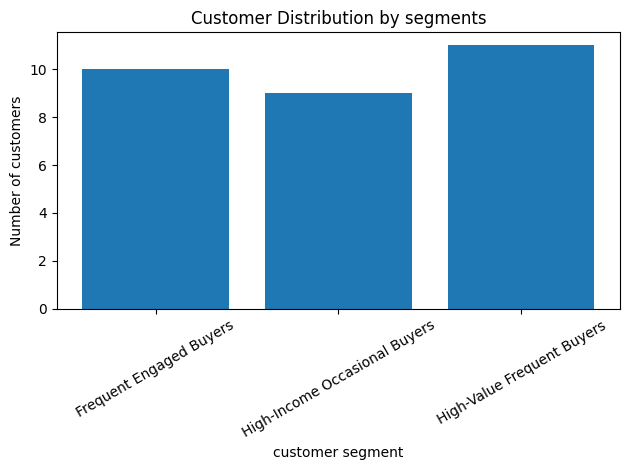

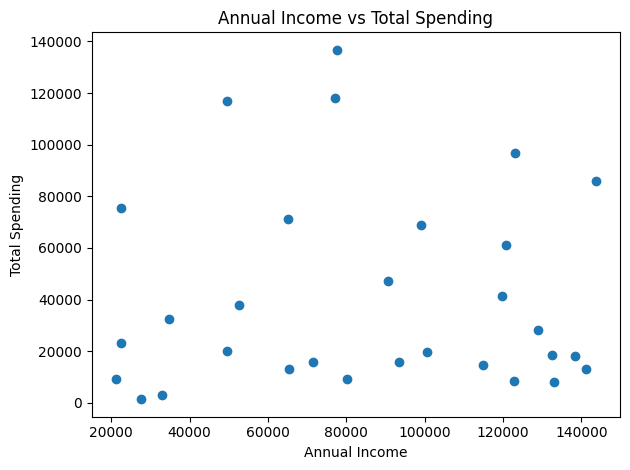

[20450.         92411.11111111 17604.81818182]


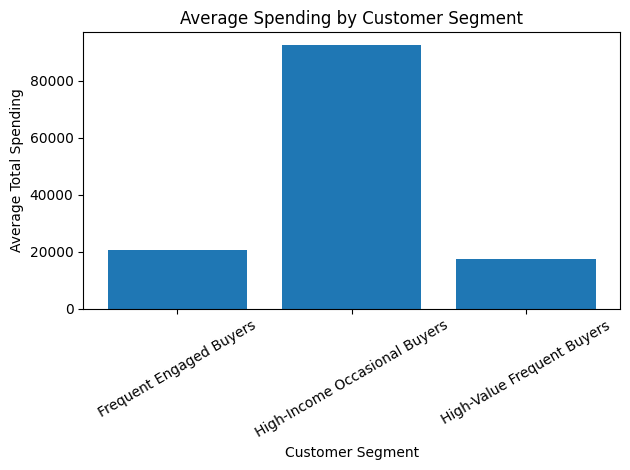

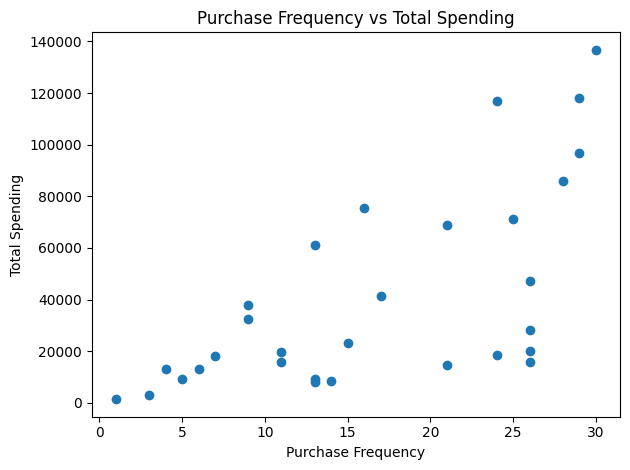

===== CUSTOMER SEGMENTATION INSIGHTS =====

Segment: Frequent Engaged Buyers
Customers: 10
Average Income: 61972.0
Average Purchase Frequency: 10.8
Average Order Value: 2040.0
Average Total Spending: 20450.0
Average Website Visits: 34.0

Segment: High-Income Occasional Buyers
Customers: 9
Average Income: 86487.88888888889
Average Purchase Frequency: 23.88888888888889
Average Order Value: 3942.6666666666665
Average Total Spending: 92411.11111111111
Average Website Visits: 65.0

Segment: High-Value Frequent Buyers
Customers: 11
Average Income: 104926.27272727272
Average Purchase Frequency: 16.272727272727273
Average Order Value: 1321.1818181818182
Average Total Spending: 17604.81818181818
Average Website Visits: 69.0909090909091


In [35]:
import numpy as np
import matplotlib.pyplot as plt


customer_id = np.arange(1, 31)
age = np.random.randint(18, 61, 30)
annual_income = np.random.randint(20000, 150001, 30)
purchase_frequency = np.random.randint(1, 31, 30)
avg_order_value = np.random.randint(300, 5001, 30)
website_visits = np.random.randint(5, 101, 30)
total_spending = purchase_frequency * avg_order_value


data = np.vstack(
    (
        customer_id,
        age,
        annual_income,
        purchase_frequency,
        avg_order_value,
        website_visits,
        total_spending
    )
).T


def Euclidean_distance(customer, standardized_features):
    return np.sqrt(
        np.sum((standardized_features - customer) ** 2, axis=1)
    )


print(f"Shape: {data.shape}")
print(f"Dimensions: {data.ndim}")
print(f"Number of customers: {len(data)}")
print(f"Minimum Age: {data[:, 1].min()}")
print(f"Maximum Age: {data[:, 1].max()}")
print(f"Average annual income: {data[:, 2].mean():.2f}")
print(f"Highest Total spending: {data[:, 6].max()}")

index = np.argmax(data[:, 6])

print(
    f"The Highest spending customer ID: {data[index, 0]} "
    f"and the customer spends {data[:, 6].max()}"
)


# #Statistical Engine
# print(data[:,2].mean())
# print(np.median(data[:,2]))
# print(data[:,6].mean())
# print(np.median(data[:,6]))
# #Vary from the avg
# print(np.std(data[:,2]))
# print(np.std(data[:,6]))
# #Analysing annual income and total spending of customers in percentiles
# print(np.percentile(data[:,2],25))
# print(np.percentile(data[:,2],75))
# print(np.percentile(data[:,6],25))
# print(np.percentile(data[:,6],75))
# #Comparing correlation between Purchase frequency and Total spending
# print(np.corrcoef(data[:,3],data[:,6]))


features = data[:, 1:]

print(features.shape)
print(features.mean(axis=0))
print(np.median(features, axis=0))
print(np.std(features, axis=0))
print(np.percentile(features, 25, axis=0))
print(np.percentile(features, 75, axis=0))


# We are going to calculate the distance between one customer to remaining 30 customers
# c=features[0]
# customer=c[np.newaxis,:]


cdata = data[:, 1:]

mean = cdata.mean(axis=0)
std = cdata.std(axis=0)

standardized_features = (cdata - mean) / std

standardized_features.mean(axis=0)
standardized_features.std(axis=0)

customer = standardized_features[0]

distances = Euclidean_distance(customer, standardized_features)

print(distances.shape)
print(distances)


# Comparing each customer with other 30 customers to get distance matrix

standardized_features.shape

A = standardized_features[:, np.newaxis, :]
B = standardized_features[np.newaxis, :, :]

distance_matrix = np.sqrt(
    np.sum((A - B) ** 2, axis=2)
)

distance_matrix.shape


#K-means foundation
# K-Means finds K groups by repeatedly assigning customers to the nearest centroid and then moving each centroid to the average position of its assigned customers.

indices = np.random.choice(30, 3, replace=False)
centroids = standardized_features[indices]

centroids.shape


# Calculate the distance from every customer to each of the 3 centroids.
# C=standardized_features[:,np.newaxis,:]
# D=centroids[np.newaxis,:,:]
# distance_to_centroids=np.sqrt(np.sum((C-D)**2,axis=2))
# distance_to_centroids.shape
# assignments=np.argmin(distance_to_centroids,axis=1)
# assignments
# # Customers belonging to seperate clusters
# cluster_0=standardized_features[assignments==0].mean(axis=0)
# cluster_1=standardized_features[assignments==1].mean(axis=0)
# cluster_2=standardized_features[assignments==2].mean(axis=0)
# centroids=np.vstack((cluster_0,cluster_1,cluster_2))
# #calculate new distance from customer to new centroid
# E=standardized_features[:,np.newaxis,:]
# F=centroids[np.newaxis,:,:]
# dist_to_ncent=np.sqrt(np.sum((E-F)**2,axis=2))
# dist_to_ncent.shape
# #reassign
# assign=np.argmin(dist_to_ncent,axis=1)
# c_0=standardized_features[assign==0].mean(axis=0)
# c_1=standardized_features[assign==1].mean(axis=0)
# c_2=standardized_features[assign==2].mean(axis=0)


#automating everything which is related to K-means

for i in range(10):

    s_f = standardized_features[:, np.newaxis, :]
    cent = centroids[np.newaxis, :, :]

    dist_to_centroid = np.sqrt(
        np.sum((s_f - cent) ** 2, axis=2)
    )

    assign = np.argmin(dist_to_centroid, axis=1)

    cluster_0 = standardized_features[assign == 0].mean(axis=0)
    cluster_1 = standardized_features[assign == 1].mean(axis=0)
    cluster_2 = standardized_features[assign == 2].mean(axis=0)

    old_centroids = centroids.copy()

    centroids = np.vstack(
        (cluster_0, cluster_1, cluster_2)
    )

    if np.allclose(old_centroids, centroids):
        print("Converged at iteration:", i)
        break


#find how many customers are in each cluster.

np.sum(assign == 0)
np.sum(assign == 1)
np.sum(assign == 2)


#calculate the average profile of each cluster

cluster_0_data = cdata[assign == 0]
cluster_0_mean = cluster_0_data.mean(axis=0)

cluster_1_data = cdata[assign == 1]
cluster_1_mean = cluster_1_data.mean(axis=0)

cluster_2_data = cdata[assign == 2]
cluster_2_mean = cluster_2_data.mean(axis=0)


print("Cluster 0:", cluster_0_mean)
print("Cluster 1:", cluster_1_mean)
print("Cluster 2:", cluster_2_mean)  # see the example to understand


#segmenting customers from clusters

condition = [assign == 0, assign == 1, assign == 2]

segment_labels = [
    "High-Income Occasional Buyers",
    "Frequent Engaged Buyers",
    "High-Value Frequent Buyers"
]

segment = np.select(
    condition,
    segment_labels,
    default='unknown'
)

customer_segments = np.column_stack(
    (customer_id, segment)
)

customer_segments


# distance from one customer to all
# distance_matrix[0]
# # np.argsort(distance_matrix[0])
# distance_matrix[0][np.argsort(distance_matrix[0])]

# sorted_indices=np.argsort(distance_matrix[0])
# customer_id[sorted_indices[1:4]]
# distance_matrix[0][sorted_indices[1:4]]


def find_similar_customers(customer_index, n):

    distances = distance_matrix[customer_index]

    sorted_indices = np.argsort(distances)

    similar_indices = sorted_indices[1:n + 1]

    similar_ids = customer_id[similar_indices]

    similar_distances = distances[similar_indices]

    result = np.column_stack(
        (similar_ids, similar_distances)
    )

    return result


clusters, counts = np.unique(
    assign,
    return_counts=True
)


mask = (annual_income > 100000) & (total_spending > 50000)

customer_id[mask]
np.sum(mask)
np.mean(total_spending[mask])


segments, counts = np.unique(
    segment,
    return_counts=True
)

print(segments)
print(counts)


plt.bar(segments, counts)

plt.xlabel("customer segment")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by segments")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


#scatter plot

plt.scatter(annual_income, total_spending)

plt.xlabel("Annual Income")
plt.ylabel("Total Spending")
plt.title("Annual Income vs Total Spending")

plt.tight_layout()
plt.show()


#avg spending of each segment

avg_spending = []

for i in segments:
    avg_spending.append(
        np.mean(total_spending[segment == i])
    )

avg_spending = np.array(avg_spending)

print(avg_spending)


plt.bar(segments, avg_spending)

plt.xlabel("Customer Segment")
plt.ylabel("Average Total Spending")
plt.title("Average Spending by Customer Segment")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


#purchase frequency vs total spending

plt.scatter(purchase_frequency, total_spending)

plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spending")
plt.title("Purchase Frequency vs Total Spending")

plt.tight_layout()
plt.show()


print("===== CUSTOMER SEGMENTATION INSIGHTS =====")


for seg in segments:

    mask = segment == seg

    print("\nSegment:", seg)
    print("Customers:", np.sum(mask))
    print("Average Income:", np.mean(annual_income[mask]))
    print("Average Purchase Frequency:", np.mean(purchase_frequency[mask]))
    print("Average Order Value:", np.mean(avg_order_value[mask]))
    print("Average Total Spending:", np.mean(total_spending[mask]))
    print("Average Website Visits:", np.mean(website_visits[mask]))

**For example if data is like this \**

| Feature            | Cluster 0 | Cluster 1 | Cluster 2 |
| ------------------ | --------: | --------: | --------: |
| Age                |     29.33 |     40.67 |     44.33 |
| Annual Income      |   ₹91,522 |   ₹71,104 |   ₹45,687 |
| Purchase Frequency |      8.58 |     21.08 |     21.50 |
| Avg Order Value    |    ₹3,096 |    ₹1,784 |    ₹3,847 |
| Website Visits     |      47.5 |     63.83 |      47.0 |
| Total Spending     |   ₹25,688 |   ₹37,729 |   ₹81,338 |


What do these clusters tell us?

Cluster 0

Younger customers
Highest average income
Lowest purchase frequency
Medium/high order value
Lowest total spending

Cluster 1

Middle-aged customers
Medium income
High purchase frequency
Lowest order value
High website visits
Moderate total spending

Cluster 2

Oldest customers
Lowest average income
Highest purchase frequency
Highest order value
Similar website visits to Cluster 0
Highest total spending